### Change of mind triggered theta power

In [7]:
%reload_ext autoreload
%autoreload 2

In [8]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import pickle

# ignore datajoint+jupyter async warnings
import warnings
warnings.simplefilter('ignore', category=DeprecationWarning)
warnings.simplefilter('ignore', category=ResourceWarning)
warnings.simplefilter('ignore', category=UserWarning)

import matplotlib.pyplot as plt

In [9]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.common import IntervalList
from spyglass.linearization.v0.main import IntervalLinearizedPosition
from spyglass.shijiegu.decodeHelpers import session2position_name

from spyglass.shijiegu.ripple_detection import loadRippleLFP_OneChannelPerElectrode
from spyglass.shijiegu.Analysis_SGU import ChangeofMind
from spyglass.shijiegu.load import load_session_name, load_position
from spyglass.shijiegu.helpers import mergeIntervals,interpolate_to_new_time
from spyglass.shijiegu.ripple_add_replay import select_subset_helper_pd
from spyglass.shijiegu.changeOfMind_figures.figure2_theta import (
triggered_theta_session, digitize_one_subset, subsets2average, triggered_theta_day)

color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}


In [4]:
list_of_days_animals = {}
seq_animals = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']#'20231111']
seq_animals[animal] = 'rev2'

In [10]:
t0 = 2
t1 = 2
delta_t = 0.04
triggered_decode_parameter_name = "params_both_max_run_time_2_state"

In [11]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure2/'

In [12]:
### Run this for data export to Dandi purpose only.
import os
import datajoint as dj

from spyglass.common.common_usage import Export, ExportSelection
paper_key = {"paper_id": "Gu2026"}

ExportSelection().start_export(**paper_key, analysis_id="ephys_theta")

[11:30:15][INFO] Spyglass: Starting {'export_id': 102}
INFO:spyglass:Starting {'export_id': 102}


In [ ]:
success = {}
for animal in ["eliot", "molly", "julio", "klein" ,"lewis"]:
    (all_theta_days, all_speed_days, all_trial_info_days, 
        t_axis,
        theta_mean, theta_sd,
        speed_mean, speed_sd) = triggered_theta_day(animal,list_of_days_animals[animal],
                                triggered_decode_parameter_name = triggered_decode_parameter_name,
                                t0 = t0, t1 = t1, delta_t = delta_t)
        
    data_filename = f"triggered_theta_{animal}_{triggered_decode_parameter_name}.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
        
    data = {
            "all_theta_days":all_theta_days, "t_axis":t_axis,
            "all_trial_info": all_trial_info_days, "all_speed_days":all_speed_days,
            "theta_mean":theta_mean, "theta_sd":theta_sd,
            "speed_mean":speed_mean, "speed_sd":speed_sd}
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {output_path}")
    
    success[animal] = 1

[2026-04-27 11:32:34,764][WARNING]: Skipped checksum for file with hash: 7e3711a5-f3a3-093e-6cf2-2d83e442c10b, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_8EGEKU4O48.nwb
[2026-04-27 11:32:40,907][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb
[2026-04-27 11:32:40,920][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb
[2026-04-27 11:32:40,958][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb
[2026-04-27 11:32:40,965][WARNING]: Skipped checksum for file with hash: c97c538f-c7b3-27d1-04d8-c8fe63e8cad9, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_KGGVXVN4ZV.nwb


t1-t0 8.02799940109253
t1-t0 9.999999284744263
No triggered decode found for  {'nwb_file_name': 'eliot20221018_.nwb', 'epoch': 4, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}


[2026-04-27 11:32:51,774][WARNING]: Skipped checksum for file with hash: 3b2d93a0-f420-7cfe-1ce9-c2fba7880815, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_9FVCVSINVL.nwb
[2026-04-27 11:32:57,772][WARNING]: Skipped checksum for file with hash: dcf7ac2f-269c-356d-e9be-dd23d83e8570, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_AAOYJJCI10.nwb
[2026-04-27 11:32:57,785][WARNING]: Skipped checksum for file with hash: dcf7ac2f-269c-356d-e9be-dd23d83e8570, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_AAOYJJCI10.nwb
[2026-04-27 11:32:57,821][WARNING]: Skipped checksum for file with hash: dcf7ac2f-269c-356d-e9be-dd23d83e8570, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_AAOYJJCI10.nwb
[2026-04-27 11:32:57,827][WARNING]: Skipped checksum for file with hash: dcf7ac2f-269c-356d-e9be-dd23d83e8570, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_AAOYJJCI10.nwb


t1-t0 9.357998609542847


[2026-04-27 11:33:08,455][WARNING]: Skipped checksum for file with hash: 70da43fd-50e5-f2b2-4cf1-28dc12ea576b, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_DHXOAEXUO5.nwb
[2026-04-27 11:33:14,514][WARNING]: Skipped checksum for file with hash: a2f4d444-d610-b6bc-5bb5-f6658a34835c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_VGTK6H1V1J.nwb
[2026-04-27 11:33:14,525][WARNING]: Skipped checksum for file with hash: a2f4d444-d610-b6bc-5bb5-f6658a34835c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_VGTK6H1V1J.nwb
[2026-04-27 11:33:14,563][WARNING]: Skipped checksum for file with hash: a2f4d444-d610-b6bc-5bb5-f6658a34835c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_VGTK6H1V1J.nwb
[2026-04-27 11:33:14,569][WARNING]: Skipped checksum for file with hash: a2f4d444-d610-b6bc-5bb5-f6658a34835c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_VGTK6H1V1J.nwb


...

[2026-04-27 11:52:37,813][WARNING]: Skipped checksum for file with hash: 389a79a9-19bf-5527-ad29-cc0b412311ea, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_OXZSJDCPGX.nwb
[2026-04-27 11:52:47,467][WARNING]: Skipped checksum for file with hash: fa9f129a-f759-774b-701c-86d2cdc91cdb, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_6U624R2CSC.nwb
[2026-04-27 11:52:47,480][WARNING]: Skipped checksum for file with hash: fa9f129a-f759-774b-701c-86d2cdc91cdb, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_6U624R2CSC.nwb
[2026-04-27 11:52:47,520][WARNING]: Skipped checksum for file with hash: fa9f129a-f759-774b-701c-86d2cdc91cdb, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_6U624R2CSC.nwb
[2026-04-27 11:52:47,526][WARNING]: Skipped checksum for file with hash: fa9f129a-f759-774b-701c-86d2cdc91cdb, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_6U624R2CSC.nwb


t1-t0 8.431995868682861
t1-t0 1.4359991550445557
t1-t0 4.999997615814209
t1-t0 9.999995231628418
t1-t0 6.923996448516846
t1-t0 4.999997615814209
t1-t0 7.02199649810791
t1-t0 4.999997615814209
t1-t0 9.999995231628418
t1-t0 9.999995231628418
t1-t0 9.999994993209839
t1-t0 9.999995231628418


[2026-04-27 11:53:02,202][WARNING]: Skipped checksum for file with hash: ab388775-be68-b001-174b-ae1127935177, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_1CT9EHP5A5.nwb
[2026-04-27 11:53:12,372][WARNING]: Skipped checksum for file with hash: 16a48701-4750-2c46-1ffc-341d0e47eb75, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_WDRTM78456.nwb
[2026-04-27 11:53:12,384][WARNING]: Skipped checksum for file with hash: 16a48701-4750-2c46-1ffc-341d0e47eb75, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_WDRTM78456.nwb
[2026-04-27 11:53:12,423][WARNING]: Skipped checksum for file with hash: 16a48701-4750-2c46-1ffc-341d0e47eb75, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_WDRTM78456.nwb
[2026-04-27 11:53:12,429][WARNING]: Skipped checksum for file with hash: 16a48701-4750-2c46-1ffc-341d0e47eb75, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_WDRTM78456.nwb


t1-t0 5.557999849319458
t1-t0 4.999999761581421
t1-t0 5.877999782562256
t1-t0 4.999999761581421
t1-t0 9.999999523162842
t1-t0 5.595999717712402
t1-t0 4.999999761581421
t1-t0 9.999999523162842
t1-t0 9.999999523162842


[2026-04-27 11:53:27,366][WARNING]: Skipped checksum for file with hash: ab118f62-a3aa-689d-c519-b0ea4ecdf82d, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_9MKMJWPQ4O.nwb
[2026-04-27 11:53:37,290][WARNING]: Skipped checksum for file with hash: 4eaa180e-da82-aab4-bcea-3985cab95537, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_UQ8XX5NVP9.nwb
[2026-04-27 11:53:37,302][WARNING]: Skipped checksum for file with hash: 4eaa180e-da82-aab4-bcea-3985cab95537, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_UQ8XX5NVP9.nwb
[2026-04-27 11:53:37,344][WARNING]: Skipped checksum for file with hash: 4eaa180e-da82-aab4-bcea-3985cab95537, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_UQ8XX5NVP9.nwb
[2026-04-27 11:53:37,351][WARNING]: Skipped checksum for file with hash: 4eaa180e-da82-aab4-bcea-3985cab95537, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_UQ8XX5NVP9.nwb


In [25]:
success

{'eliot': 1, 'molly': 1, 'julio': 1, 'klein': 1, 'lewis': 1}

In [51]:
ExportSelection().stop_export(**paper_key, analysis_id="ephys_theta")

Data successfully loaded.
Data successfully loaded.
Data successfully loaded.
Data successfully loaded.
Data successfully loaded.


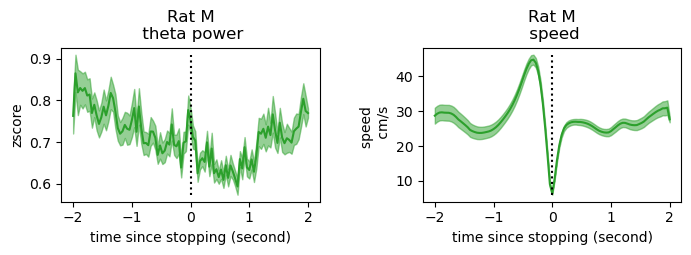

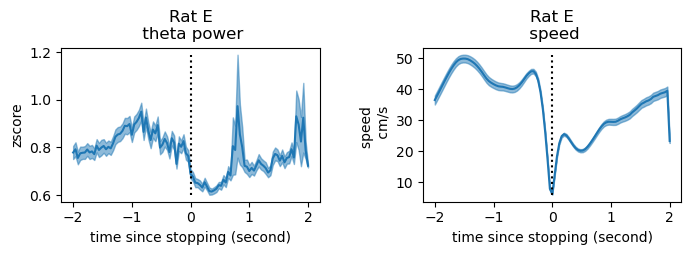

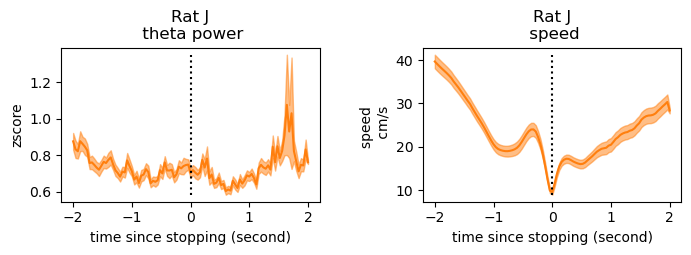

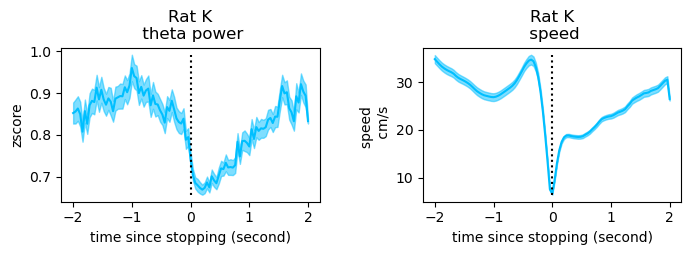

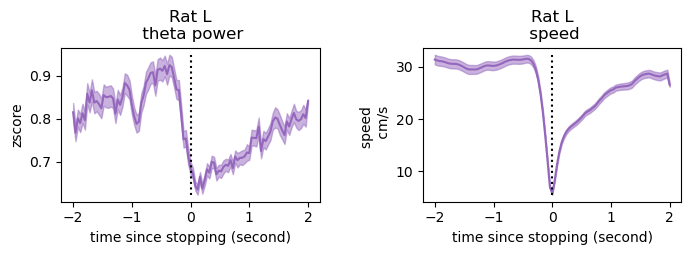

In [17]:
triggered_decode_parameter_name = "params_both_max_run_time_2_state"
for animal in ["molly","eliot","julio","klein","lewis"]:

    data_filename = f"triggered_theta_{animal}_{triggered_decode_parameter_name}.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)

    with open(output_path, 'rb') as file:
        # Deserialize the data and assign it to a variable
        data = pickle.load(file)

    # Now you can use the loaded object in your code
    print("Data successfully loaded.")

    t_axis = data["t_axis"]
    theta_mean = data["theta_mean"]
    theta_sd = data["theta_sd"]
    speed_mean = data["speed_mean"]
    speed_sd = data["speed_sd"]

    fig, axes = plt.subplots(1,2,figsize=(8, 2))
    plt.subplots_adjust(wspace = 0.4)

    axes[0].plot(t_axis, theta_mean, color = color_by_rat[animal])
    axes[0].fill_between(t_axis, theta_mean - theta_sd, theta_mean + theta_sd,
                         color = color_by_rat[animal], alpha = 0.5)
    
    axes[0].set_ylabel("zscore")
    axes[0].set_title(f"Rat {animal[0].upper()}\n theta power")
    axes[0].set_xlabel("time since stopping (second)")
    ylim1, ylim2 = np.min(theta_mean - theta_sd), np.max(theta_mean + theta_sd)
    axes[0].plot([0, 0],[ylim1,ylim2],linestyle = ":",color = 'k')
    
    axes[1].plot(t_axis, speed_mean, color = color_by_rat[animal])
    axes[1].fill_between(t_axis, speed_mean - speed_sd, speed_mean + speed_sd,
                         color = color_by_rat[animal], alpha = 0.5)
    ylim1, ylim2 = np.min(speed_mean - speed_sd), np.max(speed_mean + speed_sd)
    axes[1].plot([0, 0],[ylim1,ylim2],linestyle = ":",color = 'k')
    axes[1].set_ylabel("speed \n cm/s")
    axes[1].set_title(f"Rat {animal[0].upper()}\n speed")
    axes[1].set_xlabel("time since stopping (second)")

    file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure4/theta_and_speed_prepost{animal}.pdf"
    fig.savefig(file_path, format="pdf", bbox_inches="tight")
    

## Cycle-by-cycle analyses

In [20]:
from spyglass.shijiegu.changeOfMind_figures.figure2_theta import (trial_info_to_intervals,
    theta_cycle_analysis, chop_theta_by_cycle)

from scipy import stats
import starbars

In [21]:
triggered_decode_parameter_name = "params_both_max_run_time_2_state"
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure2/'

parameter_name_long_theta = "params_both_max_segment_run_time_2_state"
parameter_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
hpd = False

In [22]:
ExportSelection().start_export(**paper_key, analysis_id="ephys_theta_cycle_analysis")

[12:45:15][INFO] Spyglass: Export 103 in progress. Starting new.
INFO:spyglass:Export 103 in progress. Starting new.
[12:45:15][INFO] Spyglass: Resuming {'export_id': 103}
INFO:spyglass:Resuming {'export_id': 103}


In [23]:
for animal in ["molly","eliot","julio","klein","lewis"]:
    data_filename = f"triggered_theta_{animal}_{triggered_decode_parameter_name}.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
    
    with open(output_path, 'rb') as file:
        # Deserialize the data and assign it to a variable
        data = pickle.load(file)
    
    # Now you can use the loaded object in your code
    print("Data successfully loaded.")
    all_theta, all_speed, all_trial_info = data["all_theta_days"], data["all_speed_days"], data["all_trial_info"]
    
    all_extended_intervals = []
    all_remote_intervals = []
    for trial_info in all_trial_info:
        extended_intervals, remote_intervals = trial_info_to_intervals(trial_info,
                                minimum_duration_long, parameter_name_long_theta,sd,hpd,
                                parameter_name_remote, minimum_duration_remote, min_posterior)
        all_extended_intervals.append(extended_intervals)
        all_remote_intervals.append(remote_intervals)
        
    (all_features, all_responses,
     feature_names, response_names) = theta_cycle_analysis(
         all_theta, all_speed, all_extended_intervals, all_remote_intervals)

    data["all_features"] = all_features
    data["all_responses"] = all_responses
    data["feature_names"]= feature_names
    data["response_names"] = response_names

    data_filename = f"triggered_theta_{animal}_{triggered_decode_parameter_name}_cycle.pkl"
    output_path = os.path.join(output_folder,data_filename)
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {output_path}")
    

Data successfully loaded.
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure2/triggered_theta_molly_params_both_max_run_time_2_state_cycle.pkl
Data successfully loaded.
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure2/triggered_theta_eliot_params_both_max_run_time_2_state_cycle.pkl
Data successfully loaded.
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure2/triggered_theta_julio_params_both_max_run_time_2_state_cycle.pkl
Data successfully loaded.
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure2/triggered_theta_klein_params_both_max_run_time_2_state_cycle.pkl
Data successfully loaded.
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure2/triggered_theta_lewis_params_both_max_run_time_2_state_cycle.pkl


In [24]:
def sd_err(arr):
    return np.std(arr)/np.sqrt(len(arr))

def plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = False, draw_text = True):
    std = [sd_err(data1), sd_err(data2)]
    mean = [np.mean(data1), np.mean(data2)]
    ax.bar([0 + animal_ind,
                0.3 + animal_ind],mean, yerr=std, width=0.25, hatch=['', '////'],color = color_by_rat[animal], alpha=0.8)
    if draw_text:
        ax.text(animal_ind - 0.15, mean[0]+std[0] + 0.1, len(data1), fontsize = 6)
        ax.text(animal_ind + 0.3 - 0.15, mean[1]+std[1] + 0.1, len(data2), fontsize = 6)
        
    #table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data2 == 0), np.sum(data2 == 1)]])
    res = stats.ttest_ind(data1, data2)
    p_value = res.pvalue
    if p_value < 0.05 and draw_annotation:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))], ax = ax)
    return ax, p_value

### 1. Pre/post

In [28]:
animals = ["molly", "eliot", "julio", "klein", "lewis"]
def plot(feature,ylim):
    annotations_power = []
    annotations_length = []

    fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))#sharey = True)
    
    animal_ind = 0
    for animal in animals:
        # load data
        data_filename = f"triggered_theta_{animal}_{triggered_decode_parameter_name}_cycle.pkl"
        output_path = os.path.join(output_folder,data_filename)
        with open(output_path, 'rb') as file:
            # Deserialize the data and assign it to a variable
            data = pickle.load(file)
            
        all_features, all_responses = data["all_features"], data["all_responses"]
        feature_names, response_names = data["feature_names"], data["response_names"]
    
        feat_index = int(
            np.argwhere([f == feature for f in feature_names]).ravel()
        )
        
        data1 = all_responses[all_features[:,feat_index] > 0,0] #power
        data2 = all_responses[all_features[:,feat_index] != 1,0] #power
        ax, p_value = plot_one_axis(data1, data2, animal_ind, axes[0], animal,
                      draw_annotation = False, draw_text = False)
        if p_value <= 0.01:
            annotations_power.append((animal_ind, animal_ind + 0.3, np.round(p_value, 4)))
        
        # length
        data1 = all_responses[all_features[:,feat_index] > 0,1] #length
        data2 = all_responses[all_features[:,feat_index] != 1,1] #length
        ax, p_value = plot_one_axis(data1, data2, animal_ind, axes[1], animal,
                      draw_annotation = False, draw_text = False)
        if p_value <= 0.01:
            annotations_length.append((animal_ind, animal_ind + 0.3, np.round(p_value, 4)))

        
        animal_ind = animal_ind + 1

    axes[0].set_ylabel("A.U.")
    axes[1].set_ylabel("seconds")
    axes[0].set_xlabel("subject")
    axes[0].set_xlabel("subject")
    axes[0].set_title(f"{feature}\ntheta power")
    axes[1].set_title(f"{feature}\ntheta cycle length")
    axes[0].spines[['right', 'top']].set_visible(False)
    axes[1].spines[['right', 'top']].set_visible(False)


    axes[0].set_xticks(np.arange(len(animals)) + 0.15);
    axes[0].set_xticklabels([animal[0].upper() for animal in animals], fontsize = 11);
    axes[1].set_xticks(np.arange(len(animals)) + 0.15);
    axes[1].set_xticklabels([animal[0].upper() for animal in animals], fontsize = 11);
    

    starbars.draw_annotation(annotations_power, axes[0])
    starbars.draw_annotation(annotations_length, axes[1])

    

    plt.subplots_adjust(hspace=0.3)
    fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 
    axes[1].set_ylim([0.1,ylim])
    
    file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure4/theta_{feature}.pdf"
    fig.savefig(file_path, format="pdf", bbox_inches="tight")

5.005 0.03
5.005 0.03
5.005 0.03
5.005 0.03
5.005 0.03
5.005 0.03
5.005 0.03


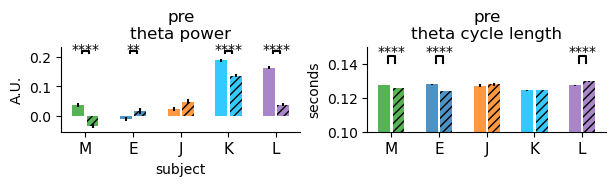

In [29]:
plot("pre",0.15)

### 2. Extended

In [30]:
feature_names

['pre', 'speed', 'extended', 'remote']

5.005 0.03
5.005 0.03
5.005 0.03
5.005 0.03
5.005 0.03
5.005 0.03


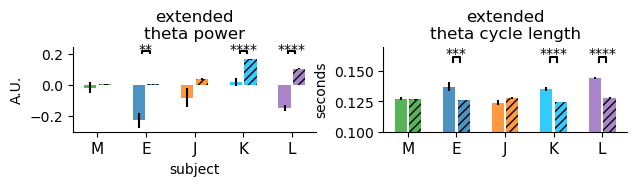

In [31]:
plot('extended',0.17)

### 3. Remote

5.005 0.03
5.005 0.03
5.005 0.03
5.005 0.03
5.005 0.03
5.005 0.03
5.005 0.03


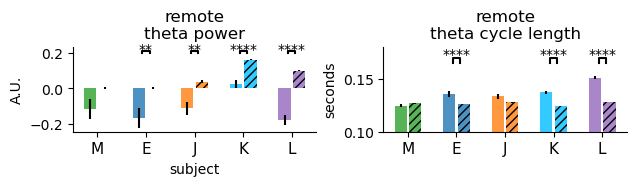

In [32]:
plot('remote',0.18)

## GLM for cycle analyses

### Mixed linear effect: all animals

In [42]:
animals = ["molly","eliot","lewis","julio","klein"]

GLM_xy = []
for animal in animals:
    # load data
    data_filename = f"triggered_theta_{animal}_{triggered_decode_parameter_name}_cycle.pkl"
    output_path = os.path.join(output_folder,data_filename)
    with open(output_path, 'rb') as file:
        # Deserialize the data and assign it to a variable
        data = pickle.load(file)
        
    all_features, all_responses = data["all_features"], data["all_responses"]
    feature_names, response_names = data["feature_names"], data["response_names"]

    animal_category = [a == animal for a in animals]
    for ind in range(len(all_features)):
        GLM_xy.append(animal_category + [f for f in all_features[ind]]+
            [r for r in all_responses[ind]])

GLM_xy = np.array(GLM_xy)

In [43]:
feature_names

['pre', 'speed', 'extended', 'remote']

In [44]:
import starbars
import statsmodels.api as sm

In [45]:
## Model 1: no theta or with theta
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_xy[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["pre-stopping"] = GLM_xy[:,(len(animals))]
feature_dict["speed"] = GLM_xy[:,(len(animals)+1)]
feature_dict["local-extended"] = GLM_xy[:,(len(animals)+2)]
feature_dict["remote"] = GLM_xy[:,(len(animals)+3)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y_power = GLM_xy[:,-2] #power
y_length = GLM_xy[:,-1] #power

"""a) Linear Effect - Power"""
ols_model_power = sm.OLS(y_power,X)
ols_result1 = ols_model_power.fit()

"""b) Linear Effect - Length"""
ols_model_length = sm.OLS(y_length,X)
ols_result2 = ols_model_length.fit()

In [46]:
## if do not wish to plot rat baselines
def model2numbers(ols_result):
    coef_names = ols_result.params.keys()
    coef_est = np.array(ols_result.params)
    pvalues = ols_result.pvalues
    CI = ols_result.conf_int(alpha=0.05)
    #yerr = np.vstack((np.array(CI[0]).reshape((1,-1)), np.array(CI[1]).reshape((1,-1)))) # 2 x coefficients

    coef_names_subset_ind = ["Rat" not in name and "cons" not in name for name in coef_names]
    coef_names = np.array(coef_names)[coef_names_subset_ind]
    coef_est = coef_est[coef_names_subset_ind]
    pvalues = pvalues[coef_names_subset_ind]
    CI = CI.loc[coef_names]

    return ols_result.params, coef_names, coef_est, pvalues, CI#, yerr

In [47]:
print(ols_result1)
print(ols_result2)

4.180000000000001 0.03
4.180000000000001 0.03
4.180000000000001 0.03
4.180000000000001 0.03
4.180000000000001 0.03
4.180000000000001 0.03
4.180000000000001 0.03


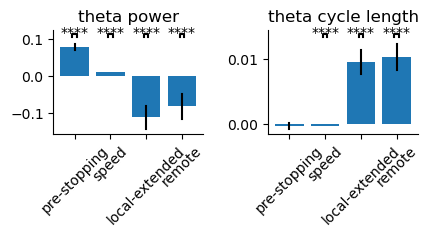

In [48]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,2,figsize=(5, 3))
annotation0 = []
annotation1 = []

#### axis 0
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result1)
axes[0].bar(coef_names, coef_est, error_kw=dict(color='k'))
for coef_name in coef_names:
    axes[0].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        annotation0.append((coef_ind, coef_ind, np.round(pvalue, 4)))
        #starbars.draw_annotation([], ax = axes[0])
        
starbars.draw_annotation(annotation0, ax = axes[0])
axes[0].set_xticks(np.arange(len(coef_names)))
axes[0].set_xticklabels(coef_names, rotation=45)
axes[0].set_title("theta power")


#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result2)

axes[1].bar(coef_names, coef_est, error_kw=dict(color='k'))
for coef_name in coef_names:
    axes[1].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        annotation1.append((coef_ind, coef_ind, np.round(pvalue, 4)))
        #starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[1], color = 'k')

starbars.draw_annotation(annotation1, ax = axes[1])
axes[1].set_xticks(np.arange(len(coef_names)))
axes[1].set_xticklabels(coef_names, rotation=45)
axes[1].set_title("theta cycle length")

# theta_point_est = coef_pd.loc["theta"]
# theta_CI = CI.loc["theta"]
# print(f"Fold change of the effect of remote theta content is {theta_point_est}, with 95% bound: {theta_CI[0],theta_CI[1]}")
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

axes[0].spines[['right', 'top']].set_visible(False)
axes[1].spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure4/theta_property_mixed_GLM.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

In [49]:
ols_result1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.132
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     1502.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:09:02   Log-Likelihood:                -59253.
No. Observations:               79146   AIC:                         1.185e+05
Df Residuals:                   79137   BIC:                         1.186e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.2237      0.003    -65.819      0.000      -0.230      -0.217
Rat M             -0.1031      0.005    -21.146      0.000      -0.113      -0.094
Rat E             -0.1300      0.004    -34.906      0.000      -0.137      -0.123
Rat L              0.0029      0.003      0.881      0.378      -0.004       0.009
Rat J             -0.0580      0.005    -12.414      0.000      -0.067      -0.049
Rat K              0.0644      0.003     19.732      0.000       0.058       0.071
pre-stopping       0.0779      0.004     21.160      0.000       0.071       0.085
speed              0.0106      0.000    102.132      0.000       0.010       0.011
local-extended    -0.1121      0.016     -7.025      0.000      -0.143      -0.081
remote            -0.0827      0.017     -4.808      0.000      -0.116      -0.049
==============================================================================
Omnibus:                   116499.114   Durbin-Watson:                   1.102
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        428263109.970
Skew:                           8.113   Prob(JB):                         0.00
Kurtosis:                     363.003   Cond. No.                     6.92e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.78e-26. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [50]:
ols_result2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     406.7
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:09:03   Log-Likelihood:             1.6506e+05
No. Observations:               79146   AIC:                        -3.301e+05
Df Residuals:                   79137   BIC:                        -3.300e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1129      0.000    565.297      0.000       0.113       0.113
Rat M              0.0226      0.000     78.814      0.000       0.022       0.023
Rat E              0.0228      0.000    104.337      0.000       0.022       0.023
Rat L              0.0241      0.000    123.474      0.000       0.024       0.024
Rat J              0.0233      0.000     84.910      0.000       0.023       0.024
Rat K              0.0201      0.000    104.698      0.000       0.020       0.020
pre-stopping      -0.0003      0.000     -1.614      0.107      -0.001    7.49e-05
speed             -0.0003   6.09e-06    -52.139      0.000      -0.000      -0.000
local-extended     0.0096      0.001     10.255      0.000       0.008       0.011
remote             0.0103      0.001     10.202      0.000       0.008       0.012
==============================================================================
Omnibus:                   200761.412   Durbin-Watson:                   1.859
Prob(Omnibus):                  0.000   Jarque-Bera (JB):       6585754283.750
Skew:                          28.192   Prob(JB):                         0.00
Kurtosis:                    1415.043   Cond. No.                     6.92e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.78e-26. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

## End here

In [210]:
feature_names

['pre', 'speed', 'extended', 'remote']

In [209]:
response_names

['power', 'length']

In [201]:
theta_subset = all_theta[ind]
speed_subset = all_speed[ind]
extended_intervals = all_extended_intervals[ind]
remote_intervals = all_remote_intervals[ind]
        
# find t0, the time of change-of-mind, which is the time when triggered decode is closest to 0
t0 = theta_subset.index[np.argmin(np.abs(theta_subset.time))]
        
# features: pre/post change-of-mind, speed, contains extended content, contains remote content
# responses: theta power, cycle length
theta_cycles = chop_theta_by_cycle(theta_subset)

In [203]:
theta_cycles

,start_time,end_time
0,1.650236e+09,1.650236e+09
1,1.650236e+09,1.650236e+09
2,1.650236e+09,1.650236e+09
3,1.650236e+09,1.650236e+09
4,1.650236e+09,1.650236e+09
...,...,...
75,1.650236e+09,1.650236e+09
76,1.650236e+09,1.650236e+09
77,1.650236e+09,1.650236e+09
78,1.650236e+09,1.650236e+09


In [186]:
from scipy.signal import find_peaks

In [190]:
start_indices

(array([ 98, 219, 326, 434, 543, 667, 782, 899]),
 {'peak_heights': array([6.22994195, 6.28318531, 6.22501203, 6.28318531, 6.28318531,
         6.23291168, 6.28318531, 6.22991656])})

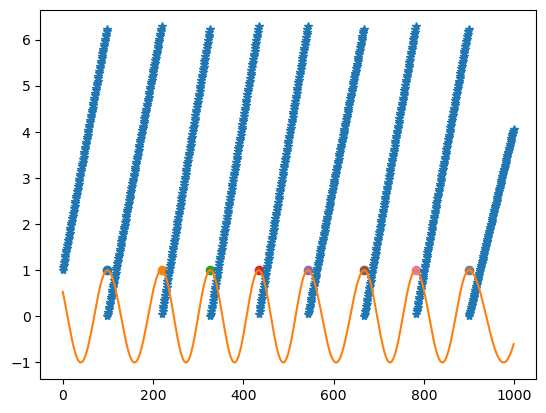

In [199]:
phase = np.array(theta_subset.phase)[:1000]
plt.plot(phase ,'*')
plt.plot(np.array(theta_subset["0"])[:1000])
start_indices, _ = find_peaks(-phase)
for s in start_indices:
    plt.scatter(s,1)

In [169]:
theta_cycles


,start_time,end_time


In [163]:
all_extended_intervals[5]

[(1650235565.6839995, 1650235565.7159996),
 (1650235565.9359994, 1650235565.9999993),
 (1650235566.7779984, 1650235566.8179984)]

In [164]:
all_remote_intervals[5]

[array([1.65023557e+09, 1.65023557e+09]),
 array([1.65023557e+09, 1.65023557e+09])]

In [159]:
feature_names

['pre', 'speed', 'extended', 'remote']

In [160]:
response_names

['power', 'length']

[19:34:39][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[19:34:39][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[19:34:39][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[19:34:40][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackG

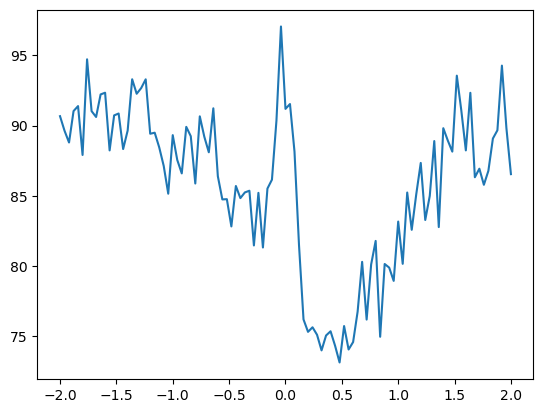

In [101]:
plt.plot(t_axis, theta_mean)
#plt.fill_between(t_axis, theta_mean - theta_sd, theta_mean + theta_sd, alpha = 0.5)

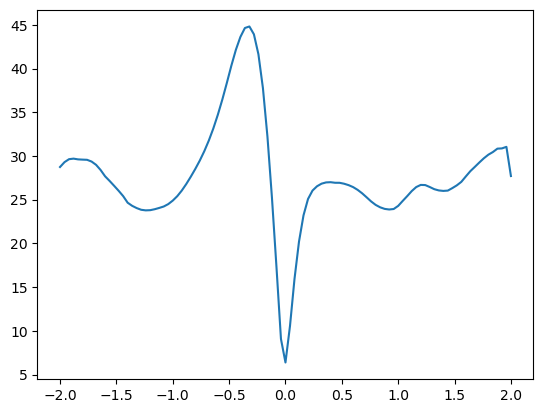

In [100]:
plt.plot(t_axis, speed_mean)
#plt.fill_between(t_axis, speed_mean - speed_sd, speed_mean + speed_sd, alpha = 0.5)

In [5]:

nwb_copy_file_name = 'molly20220419_.nwb'
session_name = "06_Seq2Session3"

In [27]:
all_theta = triggered_theta_session(
    nwb_copy_file_name, session_name,
    triggered_decode_parameter_name,
    proportion = 0.1)

[2026-03-10 09:55:11,654][WARNING]: Skipped checksum for file with hash: eac97590-4346-01cf-ced9-13e803f140a8, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_BOW1Y6KQHC.nwb
[2026-03-10 09:55:20,480][WARNING]: Skipped checksum for file with hash: 051ecf40-2192-0f76-d8a2-cb37604cfbfd, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_6EM42NZKZU.nwb
[2026-03-10 09:55:20,491][WARNING]: Skipped checksum for file with hash: 051ecf40-2192-0f76-d8a2-cb37604cfbfd, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_6EM42NZKZU.nwb
[2026-03-10 09:55:20,502][WARNING]: Skipped checksum for file with hash: 051ecf40-2192-0f76-d8a2-cb37604cfbfd, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_6EM42NZKZU.nwb
[2026-03-10 09:55:20,508][WARNING]: Skipped checksum for file with hash: 051ecf40-2192-0f76-d8a2-cb37604cfbfd, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_6EM42NZKZU.nwb


len(peak_ind) 14057
t1-t0 6.025998115539551
t1-t0 3.1819989681243896
t1-t0 9.163997173309326
t1-t0 7.049997806549072
t1-t0 4.999998331069946


In [25]:
#%debug

In [67]:
t_axis = np.arange(-2, 2+0.04, 0.04)
bins, lfps_binned = digitize_one_subset(all_theta[4], t_axis, "amplitude")

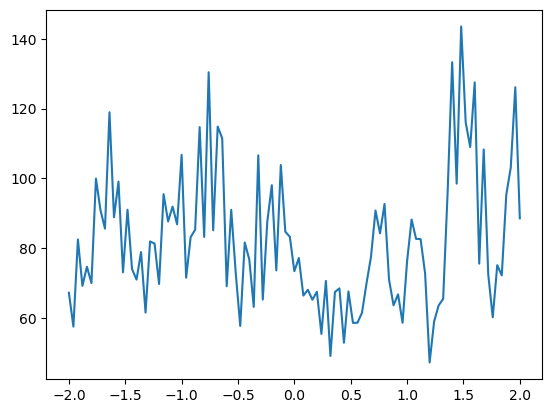

In [66]:
plt.plot(t_axis, theta_ave)

In [4]:
def triggered_theta_session(df, trialIDs, pos_info, time_type, session_mean, session_sd):
    filtered_lfps_subset_all = []

    for trialID in trialIDs:
        if time_type == "com": #change of mind
            t = df.loc[trialID].initial_time
        elif "reward" in time_type: #change of mind
            t = df.loc[trialID].timestamp_O
            
        t0, t1 = (t - 1, t + 3)
        t_axis = np.linspace(t0, t1, 4000)
        t_ind = np.logical_and(filtered_lfps_t_maze >= t0, filtered_lfps_t_maze <= t1)
        filtered_lfps_t_subset = filtered_lfps_t_maze[t_ind]
        filtered_lfps_subset = (np.mean(filtered_lfps_raw_maze[t_ind,:] ** 2, axis = 1) - session_mean) / session_sd

        pos_info_subset = select_subset_helper_pd(pos_info, (t0, t1+0.01))
        pos_info_subset = pos_info_subset.iloc[:len(filtered_lfps_subset)]
        assert len(pos_info_subset) == len(filtered_lfps_subset)
        low_speed_ind = np.array(pos_info_subset.head_speed) <= 4
        filtered_lfps_t_subset = filtered_lfps_t_subset[low_speed_ind]
        filtered_lfps_subset = filtered_lfps_subset[low_speed_ind]
        
        bins = np.digitize(filtered_lfps_t_subset, t_axis) - 1
        filtered_lfps_binned = np.zeros_like(t_axis)
        filtered_lfps_binned_count = np.zeros_like(t_axis)
        for ind in range(len(bins)):
            target_ind = bins[ind]
            filtered_lfps_binned[target_ind] += filtered_lfps_subset[ind]
            filtered_lfps_binned_count[target_ind] += 1
        filtered_lfps_binned = filtered_lfps_binned/filtered_lfps_binned_count
    
        filtered_lfps_subset_all.append(filtered_lfps_binned)
    filtered_lfps_subset_all = np.array(filtered_lfps_subset_all)
    
    t_axis = t_axis - t

    return filtered_lfps_subset_all, t_axis

In [5]:
nwb_file_name = "eliot20221021.nwb"

In [6]:
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
animal = nwb_file_name[:5]

In [7]:
session_interval, sleep_interval = load_session_name(nwb_copy_file_name)
print(session_interval)

['02_Seq2Session1', '04_Seq2Session2', '06_Seq2Session3', '08_Seq2Session4']


In [8]:
#df[df.rewardNum == 1]

In [9]:
com_all = []
reward_all = []

for session_name in session_interval:

    position_valid_times = (IntervalList & {'nwb_file_name': nwb_copy_file_name,
                                            'interval_list_name': session_name}).fetch1('valid_times')
    epoch_pos_name = session2position_name(nwb_copy_file_name, session_name)

    q = {"proportion": 0.1,
     "delta_t_minus":5, "delta_t_plus":5,
     "max_flag":1}

    q["nwb_file_name"] = nwb_copy_file_name
    q["epoch"] = session_name[:2]
    df = ChangeofMind().fetch1_dataframe(q)         # trials with long theta

    df_com = df[df.change_of_mind]
    df_nonreward = df[df.rewardNum == 1]

    #filtered_lfps, filtered_lfps_t, CA1TetrodeInd, CCTetrodeInd = loadRippleLFP_OneChannelPerElectrode(
    #    nwb_copy_file_name,session_name,position_valid_times,'artifact removed filtered data',1)
    

    (filtered_lfps_raw, filtered_lfps_t,
     _2, _3) = loadRippleLFP_OneChannelPerElectrode(
         nwb_copy_file_name,
         session_name,position_valid_times,'filtered data',1)

    position_info = load_position(nwb_copy_file_name,epoch_pos_name)
    position_info_upsample = interpolate_to_new_time(position_info, filtered_lfps_t)

    t0, t1 = (df.loc[1].timestamp_O, df.loc[80].timestamp_O)

    t_ind = np.logical_and(filtered_lfps_t >= t0, filtered_lfps_t <= t1)

    # get session threshold
    filtered_lfps_raw_maze = filtered_lfps_raw[t_ind]
    filtered_lfps_t_maze = filtered_lfps_t[t_ind]
    session_mean = np.mean(np.mean(filtered_lfps_raw_maze ** 2, axis = 1))
    session_sd = np.std(np.mean(filtered_lfps_raw_maze ** 2, axis = 1))

    lfp_com, t_axis_com = return_triggered_ripples(df, df_com.index[df_com.index < 80], position_info_upsample,
                                                            "com", session_mean, session_sd)

    lfp_reward, t_axis_reward = return_triggered_ripples(df, df_nonreward.index[df_nonreward.index < 80],position_info_upsample,
                                                            "reward", session_mean, session_sd)

    com_all.append(lfp_com)
    reward_all.append(lfp_reward)

com_all = np.vstack(com_all)
reward_all = np.vstack(reward_all)

[2026-01-11 18:12:38,631][WARNING]: Skipped checksum for file with hash: 626d7420-9063-346e-2144-88b98cf08637, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_WUIWB998PT.nwb


Using LFP from these eletrodes: 
[ 0  2  4  5 13 14 16 17 20 23 26 27 28 29 30 31]




[2026-01-11 18:12:55,717][WARNING]: Skipped checksum for file with hash: 4f1e870e-1a7d-11cb-9683-018f12baa832, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_0YUODHKC7Q.nwb
[2026-01-11 18:12:55,724][WARNING]: Skipped checksum for file with hash: 4f1e870e-1a7d-11cb-9683-018f12baa832, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_0YUODHKC7Q.nwb
[2026-01-11 18:12:55,731][WARNING]: Skipped checksum for file with hash: 4f1e870e-1a7d-11cb-9683-018f12baa832, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_0YUODHKC7Q.nwb
[2026-01-11 18:12:55,735][WARNING]: Skipped checksum for file with hash: 4f1e870e-1a7d-11cb-9683-018f12baa832, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_0YUODHKC7Q.nwb
[2026-01-11 18:13:07,702][WARNING]: Skipped checksum for file with hash: e44d0a0c-2274-73bd-441e-61bcd4107fc3, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_GUR45AHIGJ.nwb


Using LFP from these eletrodes: 
[ 0  2  4  5 13 14 16 17 20 23 26 27 28 29 30 31]




[2026-01-11 18:13:21,587][WARNING]: Skipped checksum for file with hash: c7d250de-6acf-a955-0f3b-55eb05641cce, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_RG4SJHR15M.nwb
[2026-01-11 18:13:21,598][WARNING]: Skipped checksum for file with hash: c7d250de-6acf-a955-0f3b-55eb05641cce, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_RG4SJHR15M.nwb
[2026-01-11 18:13:21,609][WARNING]: Skipped checksum for file with hash: c7d250de-6acf-a955-0f3b-55eb05641cce, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_RG4SJHR15M.nwb
[2026-01-11 18:13:21,616][WARNING]: Skipped checksum for file with hash: c7d250de-6acf-a955-0f3b-55eb05641cce, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_RG4SJHR15M.nwb
[2026-01-11 18:13:31,208][WARNING]: Skipped checksum for file with hash: af46516c-7d03-7e75-cf5e-70a2e1064c76, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_15ETSO398L.nwb


Using LFP from these eletrodes: 
[ 0  2  4  5 13 14 16 17 20 23 26 27 28 29 30 31]




[2026-01-11 18:13:43,924][WARNING]: Skipped checksum for file with hash: 42aff248-84f7-3b8e-44ac-b9ac98424906, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_YJI6PB1PH0.nwb
[2026-01-11 18:13:43,934][WARNING]: Skipped checksum for file with hash: 42aff248-84f7-3b8e-44ac-b9ac98424906, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_YJI6PB1PH0.nwb
[2026-01-11 18:13:43,945][WARNING]: Skipped checksum for file with hash: 42aff248-84f7-3b8e-44ac-b9ac98424906, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_YJI6PB1PH0.nwb
[2026-01-11 18:13:43,952][WARNING]: Skipped checksum for file with hash: 42aff248-84f7-3b8e-44ac-b9ac98424906, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_YJI6PB1PH0.nwb
[2026-01-11 18:13:52,925][WARNING]: Skipped checksum for file with hash: cb6affd0-a7db-d78a-f991-971eb73dbe89, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_4I62DJC829.nwb


Using LFP from these eletrodes: 
[ 0  2  4  5 13 14 16 17 20 23 26 27 28 29 30 31]




[2026-01-11 18:14:06,353][WARNING]: Skipped checksum for file with hash: 2522622b-d0fd-2933-dbfb-9da862065fc2, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_AGBTZIVBTP.nwb
[2026-01-11 18:14:06,364][WARNING]: Skipped checksum for file with hash: 2522622b-d0fd-2933-dbfb-9da862065fc2, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_AGBTZIVBTP.nwb
[2026-01-11 18:14:06,374][WARNING]: Skipped checksum for file with hash: 2522622b-d0fd-2933-dbfb-9da862065fc2, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_AGBTZIVBTP.nwb
[2026-01-11 18:14:06,380][WARNING]: Skipped checksum for file with hash: 2522622b-d0fd-2933-dbfb-9da862065fc2, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_AGBTZIVBTP.nwb


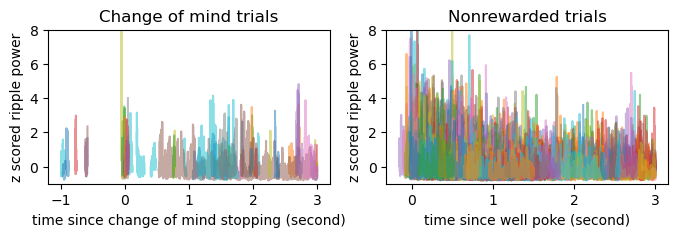

In [10]:
fig, axes = plt.subplots(1,2,figsize = (8, 2),sharey = True)

ax = axes[0]
for lfp in com_all:
    ax.plot(t_axis_com, lfp, alpha = 0.5)
mean = np.mean(com_all,axis = 0)
#std = np.std(com_all,axis = 0)

#ax.plot(t_axis_com, mean, color = 'k', linewidth = 2, label = "mean trace")
#ax.fill_between(t_axis_com, mean - std, mean + std, color = 'magenta', alpha = 0.5)
ax.set_title("Change of mind trials")
ax.set_xlabel("time since change of mind stopping (second)")
ax.set_ylabel("z scored ripple power")
#ax.legend()

ax1 = axes[1]
for lfp in reward_all:
    ax1.plot(t_axis_reward, lfp, alpha = 0.5)
mean = np.mean(reward_all,axis = 0)
#std = np.std(reward_all,axis = 0)

#ax1.plot(t_axis_reward, mean, color = 'k', linewidth = 2, label = "mean trace")
#ax1.fill_between(t_axis_reward, mean - std, mean + std, color = 'magenta', alpha = 0.5)
ax1.set_title("Nonrewarded trials")
ax1.set_xlabel("time since well poke (second)")
ax1.set_ylabel("z scored ripple power")
ax1.tick_params(labelleft=True)
ax1.set_ylim([-1,8])
plt.savefig(f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure2/triggered_ripple_power_{animal}.pdf',dpi=300,bbox_inches='tight')